In [2]:
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random as python_random
import tensorflow as tf 
from sklearn .metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from keras import backend as K
from tensorflow.keras.applications import vgg16
from tensorflow.keras.layers import Dense, Flatten, Dropout,GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam




I0000 00:00:1782909604.316603    1262 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782909604.974798    1262 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782909608.357831    1262 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
dataset_path = "/home/mariam/Projects/covid-Xray-finetuning/data/COVID-19_Radiography_Dataset"

print("Folders in dataset:")
print(os.listdir(dataset_path))

Folders in dataset:
['Covid19-dataset']


In [4]:
train_path = "/home/mariam/Projects/covid-Xray-finetuning/data/COVID-19_Radiography_Dataset/Covid19-dataset/train"
test_path = "/home/mariam/Projects/covid-Xray-finetuning/data/COVID-19_Radiography_Dataset/Covid19-dataset/test"

print("Train classes:")
print(os.listdir(train_path))

print("\nTest classes:")
print(os.listdir(test_path))

Train classes:
['Viral Pneumonia', 'Covid', 'Normal']

Test classes:
['Viral Pneumonia', 'Covid', 'Normal']


In [5]:
np.random.seed(42)
tf.random.set_seed(42)


In [6]:
base_model = vgg16.VGG16(weights='imagenet')
print(base_model.summary())

E0000 00:00:1782909617.792858    1262 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1782909617.794047    6045 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1782909617.825921    1262 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
W0000 00:00:1782909618.050757    1262 cpu_allocator_impl.cc:82] Allocation of 411041792 exceeds 10% of free system memory.
W0000 00:00:1782909618.306671    1262 cpu_allocator

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

None


In [7]:
Height=224
Width=224
Batch_size=32

In [8]:
train_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

In [9]:
#For augmentation, you can use the following code:
# train_gen = ImageDataGenerator(
#     rescale=1./255,
#     rotation_range=20,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     shear_range=0.2,
#     zoom_range=0.2,
#     horizontal_flip=True)

In [10]:
train_path = "/home/mariam/Projects/covid-Xray-finetuning/data/COVID-19_Radiography_Dataset/Covid19-dataset/train"
test_path = "/home/mariam/Projects/covid-Xray-finetuning/data/COVID-19_Radiography_Dataset/Covid19-dataset/test"
#Normalizing the images and creating the training and testing datasets
train_data = train_gen.flow_from_directory (
    train_path,
    target_size=(Height, Width),
    batch_size=Batch_size,
    class_mode='sparse',
    shuffle=True,
   )
test_data = test_gen.flow_from_directory (
    test_path,
    target_size=(Height, Width),
    batch_size=Batch_size,
    class_mode='sparse',
    shuffle=False,
   )

 

Found 251 images belonging to 3 classes.


Found 66 images belonging to 3 classes.


In [11]:
print(train_data.class_indices)

{'Covid': 0, 'Normal': 1, 'Viral Pneumonia': 2}


In [12]:
total_image=np.concatenate([train_data.labels, test_data.labels])

In [13]:
print("Normal images:", np.sum(total_image == 0))
print("Covid images:", np.sum(total_image == 1))
print("Viral Pneumonia images:", np.sum(total_image == 2))

Normal images: 137
Covid images: 90
Viral Pneumonia images: 90


In [14]:
train_data.labels.shape

(251,)

In [15]:
print(train_data.labels[:500])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [16]:
np.unique(train_data.labels)

array([0, 1, 2], dtype=int32)

In [17]:
#Display images
image, label = next(train_data)




In [18]:
#per Batch
label.shape

(32,)

In [19]:
def plot_images(image_arr, label_arr, class_indices):
    fig, axes = plt.subplots(2, 5, figsize=(15, 8))
    axes = axes.flatten()

    for img, lbl, ax in zip(image_arr, label_arr, axes):
        ax.imshow(img)

        label = list(class_indices.keys())[
            list(class_indices.values()).index(int(lbl))
        ]

        ax.set_title(label)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    

In [20]:
label[:5]

array([1., 0., 1., 0., 1.], dtype=float32)

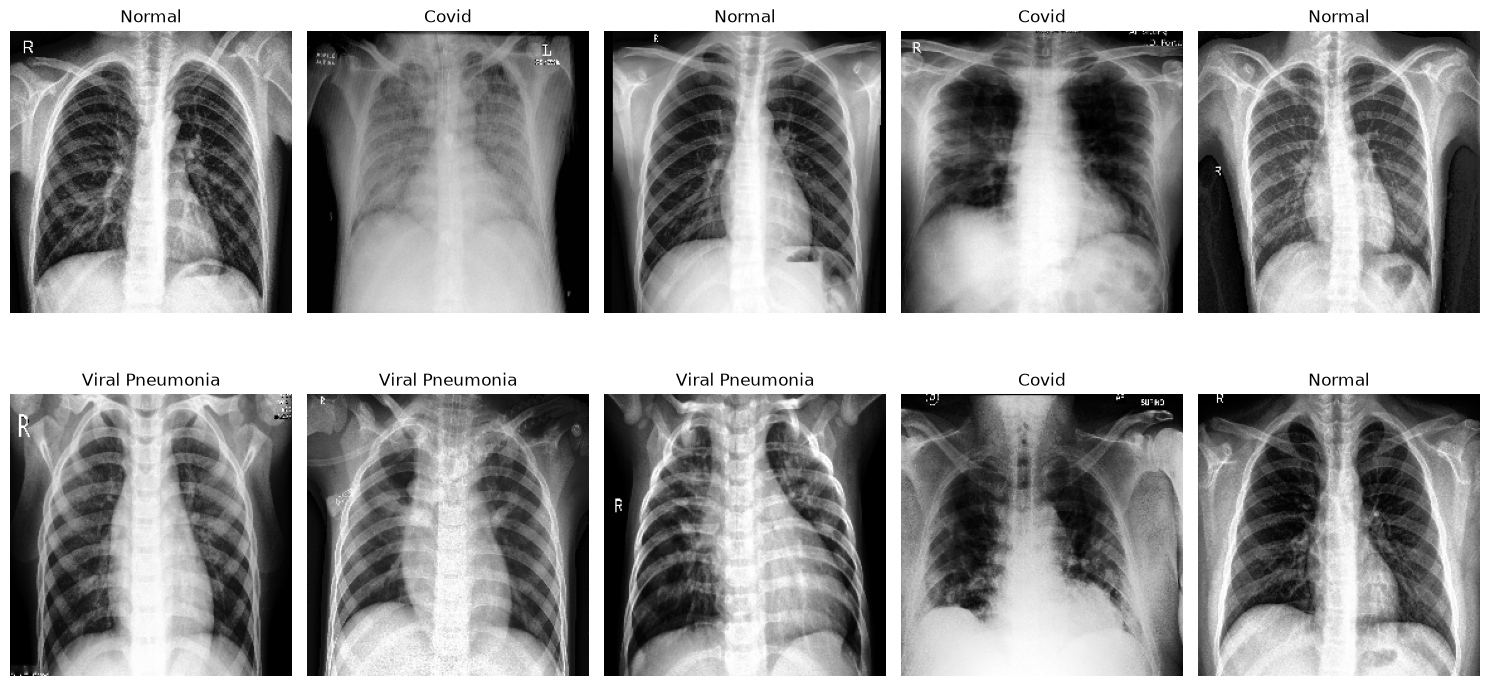

In [21]:
plot_images(image[:15], label[:15], train_data.class_indices)

In [22]:
#Importing the VGG16 model and adding custom layers for classification
base_model =vgg16.VGG16(weights='imagenet', include_top=False, input_shape=(Height, Width, 3))


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 41s 1us/step


In [ ]:
#Freezing the layers of the base model to prevent them from being updated during training

for layer in base_model.layers:
    layer.trainable = False

In [24]:
num_classes = len(train_data.class_indices)
print("Number of classes:", num_classes)

Number of classes: 3


In [33]:
model=Sequential()
model.add(base_model)
model.add(GlobalAveragePooling2D())
#model.add(Dense(512, activation='relu'))
#model.add(Dropout(0.5))
#model.add(Dense(256, activation='relu'))
#model.add(Dropout(0.4))
#model.add(Dense(128, activation='relu'))
#model.add(Dropout(0.3))
#model.add(Dense(num_classes, activation='softmax'))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))




In [34]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,912,579 (56.89 MB)

 Trainable params: 197,891 (773.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [47]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [56]:
#Adding callbacks for early stopping and model checkpointing
checkpoint = ModelCheckpoint(
    "../models/vgg16_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min')

In [57]:
history = model.fit(
    train_data,
    epochs=50,
    validation_data=test_data,
    callbacks=[checkpoint, early_stopping],
    verbose=1,
    shuffle=True
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9562 - loss: 0.1329
Epoch 1: val_accuracy improved from None to 0.87879, saving model to ../models/vgg16_model.keras

Epoch 1: finished saving model to ../models/vgg16_model.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 47s 6s/step - accuracy: 0.9562 - loss: 0.1329 - val_accuracy: 0.8788 - val_loss: 0.2246
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9721 - loss: 0.1115
Epoch 2: val_accuracy improved from 0.87879 to 0.93939, saving model to ../models/vgg16_model.keras

Epoch 2: finished saving model to ../models/vgg16_model.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 44s 6s/step - accuracy: 0.9721 - loss: 0.1115 - val_accuracy: 0.9394 - val_loss: 0.1662
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9641 - loss: 0.1280
Epoch 3: val_accuracy did not improve from 0.93939
8/8 ━━━━━━━━━━━━━━━━━━━━ 42s 5s/step - accuracy: 0.9641 - loss: 0.1280 - val_accuracy: 0.8788 - val_loss: 0.2059
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/st

In [62]:
print("Best Validation Accuracy:", max(history.history["val_accuracy"]))

Best Validation Accuracy: 0.9848484992980957


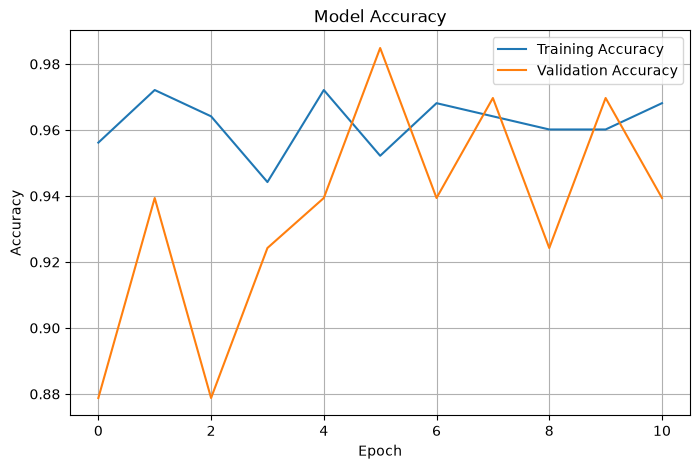

In [59]:

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

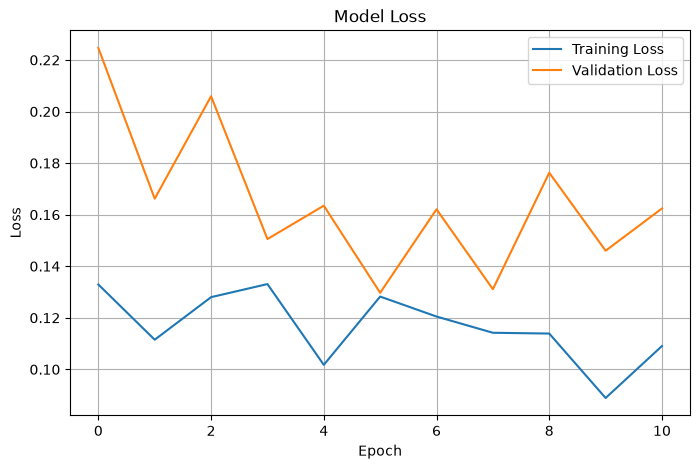

In [60]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [61]:
y_pred = model.predict(test_data)

3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step


In [63]:
print("Best Validation Accuracy:", max(history.history["val_accuracy"]))

Best Validation Accuracy: 0.9848484992980957


In [66]:

y_pred = model.predict(test_data)
y_pred = np.argmax(y_pred, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step


In [67]:
print(model.output_shape)

print(y_true.shape)
print(y_pred.shape)

print(y_pred[:5])

(None, 3)
(66,)
(66,)
[0 0 0 0 0]


In [68]:
print(type(y_true))
print(type(y_pred))

print(y_true.dtype)
print(y_pred.dtype)

print(np.unique(y_true))
print(np.unique(y_pred))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
int32
int64
[0 1 2]
[0 1 2]


In [69]:
print(y_true[:10])

[0 0 0 0 0 0 0 0 0 0]


In [70]:

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[26  0  0]
 [ 0 19  1]
 [ 0  0 20]]


Text(70.38563368055554, 0.5, 'True Label')

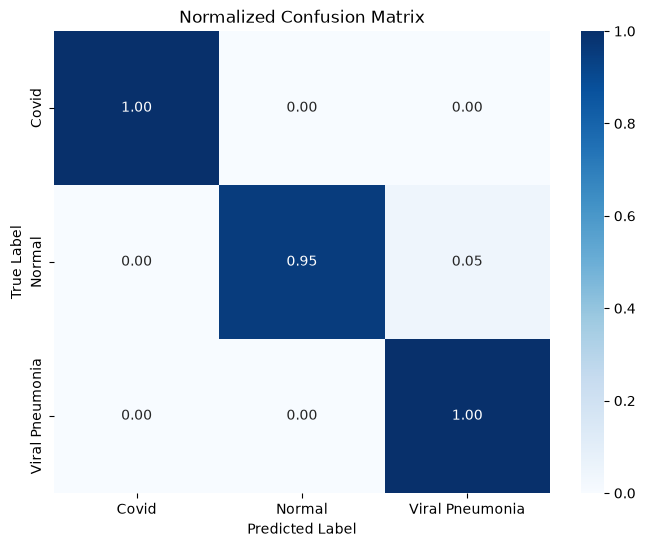

In [71]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=test_data.class_indices.keys(),
    yticklabels=test_data.class_indices.keys()
)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


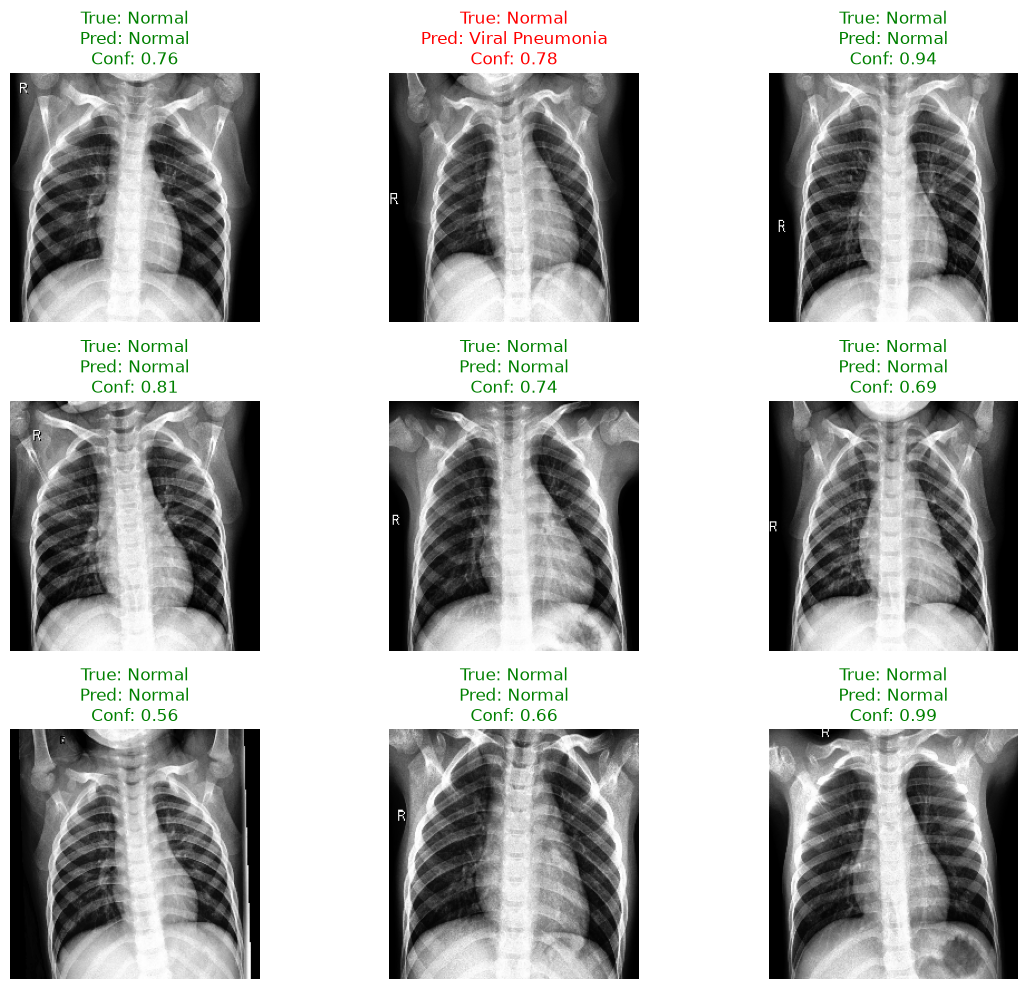

In [73]:

images, labels = next(iter(test_data))

preds = model.predict(images)
pred_classes = np.argmax(preds, axis=1)

class_names = list(test_data.class_indices.keys())

plt.figure(figsize=(12, 10))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])

    true_label = class_names[int(labels[i])]
    pred_label = class_names[pred_classes[i]]
    confidence = np.max(preds[i])

    color = "green" if true_label == pred_label else "red"

    plt.title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [74]:


images, labels = [], []

for i in range(9):
    img_path = test_data.filepaths[i]
    
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img = tf.keras.utils.img_to_array(img) / 255.0
    
    images.append(img)
    labels.append(test_data.classes[i])

images = np.array(images)
labels = np.array(labels)

In [75]:
preds = model.predict(images)
pred_classes = np.argmax(preds, axis=1)

class_names = list(test_data.class_indices.keys())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


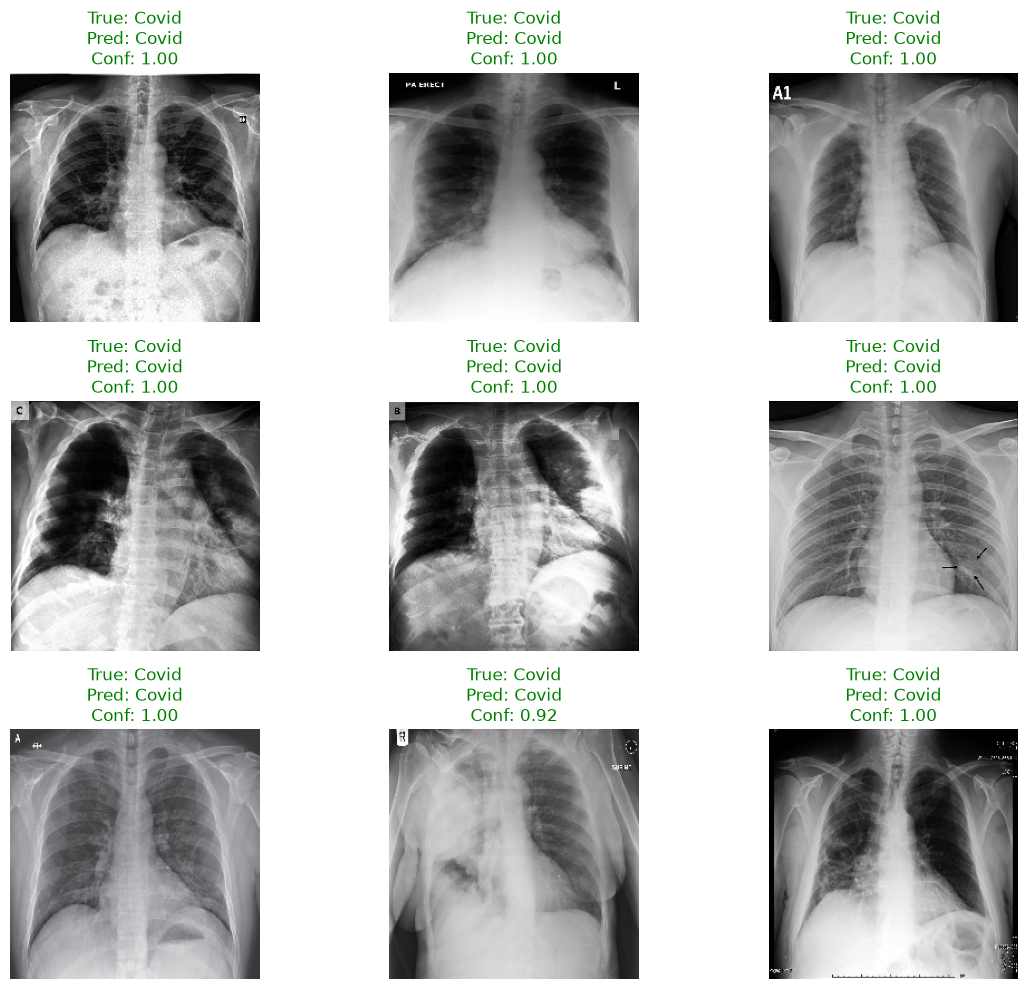

In [76]:
plt.figure(figsize=(12, 10))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])

    true_label = class_names[int(labels[i])]
    pred_label = class_names[pred_classes[i]]
    confidence = np.max(preds[i])

    color = "green" if true_label == pred_label else "red"

    plt.title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()